<h1>Project: Medical Insurance Cost Analysis</h1>
<br><br>
<table border="1" cellpadding="6" cellspacing="0">
  <thead>
    <tr>
      <th>Parameter</th>
      <th>Description</th>
      <th>Content type</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>age</td>
      <td>Age in years</td>
      <td>integer</td>
    </tr>
    <tr>
      <td>gender</td>
      <td>Male or Female</td>
      <td>integer (1 or 2)</td>
    </tr>
    <tr>
      <td>bmi</td>
      <td>Body mass index</td>
      <td>float</td>
    </tr>
    <tr>
      <td>no_of_children</td>
      <td>Number of children</td>
      <td>integer</td>
    </tr>
    <tr>
      <td>smoker</td>
      <td>Whether smoker or not</td>
      <td>integer (0 or 1)</td>
    </tr>
    <tr>
      <td>region</td>
      <td>Which US region - NW, NE, SW, SE</td>
      <td>integer (1, 2, 3 or 4 respectively)</td>
    </tr>
    <tr>
      <td>charges</td>
      <td>Annual Insurance charges in USD</td>
      <td>float</td>
    </tr>
  </tbody>
</table>

In [1]:
%pip install seaborn

In [28]:
from pyodide.http import pyfetch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [3]:
pd.set_option("display.max_columns",None)

<h1>I. Data Preparation</h1>

<h2>A. Download Data</h2>

In [4]:
async def download(url, filename):
    response = await pyfetch(url)
    try:
        if response.status == 200:
            print("Connection to URL successfull")
            data = await response.bytes()
            with open(filename, "wb") as f:
                f.write(data)
                print(f"File {filename} successfully created")
    except Exception as e:
        print(f"Error during download: {e}")

In [5]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
filename = "medical_insurance_data.csv"
await download(url, filename)

Connection to URL successfull
File medical_insurance_data.csv successfully created


In [6]:
df = pd.read_csv(filename)
df.head()

,19,1,27.9,0,1.1,3,16884.924
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160


In [54]:
df_final.describe()

,age (years),gender,bmi,no_of_children,smoker,region,charges (USD)
count,2771.000000,2771.000000,2771.000000,2771.000000,2771.000000,2771.000000,2771.000000
mean,39.116925,1.507398,30.702360,1.102129,0.203176,2.559726,13260.062288
std,14.078815,0.500036,6.130324,1.214845,0.402435,1.130934,12153.767157
min,18.000000,1.000000,15.960000,0.000000,0.000000,1.000000,1121.870000
25%,26.000000,1.000000,26.220000,0.000000,0.000000,2.000000,4687.800000
50%,39.000000,2.000000,30.495000,1.000000,0.000000,3.000000,9304.700000
75%,51.000000,2.000000,34.770000,2.000000,0.000000,4.000000,16516.745000
max,64.000000,2.000000,53.130000,5.000000,1.000000,4.000000,63770.430000


<h2>B. Data Cleaning</h2>
<h3>1. Data Integrity and NaN</h3>

In [7]:
newHeader = [
"age (years)",
"gender",
"bmi",
"no_of_children",
"smoker",
"region",	
"charges (USD)"]

df.columns = newHeader
df.head(2)


,age (years),gender,bmi,no_of_children,smoker,region,charges (USD)
0,18,2,33.77,1,0,4,1725.5523
1,28,2,33.00,3,0,4,4449.4620


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age (years)     2771 non-null   object 
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_children  2771 non-null   int64  
 4   smoker          2771 non-null   object 
 5   region          2771 non-null   int64  
 6   charges (USD)   2771 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 130.0+ KB


In [9]:
summary = {}

for col in df.columns:
    mask = ~df[col].apply(lambda x: isinstance(x, (int, float)))
    if mask.any():
        summary[col] = df.loc[mask, col].value_counts()
# Display
for col, values in summary.items():
    print(f"\nColumn: {col}")
    print(values)


Column: age (years)
age (years)
18    148
19    141
45     62
47     62
52     62
23     62
22     60
28     60
21     60
26     60
54     60
46     60
51     60
25     58
27     58
20     58
53     58
48     58
50     58
24     56
49     56
44     56
41     56
56     56
30     56
32     56
33     54
43     54
42     54
29     54
57     54
31     54
40     54
34     52
58     52
55     52
59     52
37     52
39     50
36     50
38     50
35     50
62     48
61     46
60     46
64     46
63     46
?       4
Name: count, dtype: int64

Column: smoker
smoker
0    2201
1     563
?       7
Name: count, dtype: int64


In [10]:
print(
    df.isnull().sum(),
    df.isin([""]).sum(),
    df.isin([" "]).sum(),
    df.isin(["Nan"]).sum(),
    df.isin(["nan"]).sum(),
    df.isin(["-"]).sum(),
    df.isin(["?"]).sum()
     )

age (years)       0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges (USD)     0
dtype: int64 age (years)       0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges (USD)     0
dtype: int64 age (years)       0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges (USD)     0
dtype: int64 age (years)       0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges (USD)     0
dtype: int64 age (years)       0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges (USD)     0
dtype: int64 age (years)       0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges (USD)     0
dtype: int64 age (years)       4
gender            0
bmi               0
no_of_children    0
sm

In [11]:
df_1 = df.replace("?", np.nan)

In [12]:
df_1.isnull().sum()

age (years)       4
gender            0
bmi               0
no_of_children    0
smoker            7
region            0
charges (USD)     0
dtype: int64

<h3>2. Data Wrangling</h3>

In [13]:
max_frequency_smoker = df_1["smoker"].mode()[0]
max_frequency_smoker
mean_age = df_1["age (years)"].astype("float").mean()
mean_age

df_2 = df_1.copy()

df_2["smoker"] = df_2["smoker"].replace(np.nan, max_frequency_smoker) #.fillna(value)
df_2["age (years)"] = df_2["age (years)"].replace(np.nan, mean_age)

df_2[["age (years)","smoker"]] = df_2[["age (years)","smoker"]].astype("int")

In [14]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age (years)     2771 non-null   int32  
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_children  2771 non-null   int64  
 4   smoker          2771 non-null   int32  
 5   region          2771 non-null   int64  
 6   charges (USD)   2771 non-null   float64
dtypes: float64(2), int32(2), int64(3)
memory usage: 130.0 KB


In [15]:
df_2["charges (USD)"] = df_2["charges (USD)"].round(2)

In [16]:
df_2.isnull().sum()

age (years)       0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges (USD)     0
dtype: int64

In [17]:
df_final = df_2.copy()
df_final.head()

,age (years),gender,bmi,no_of_children,smoker,region,charges (USD)
0,18,2,33.770,1,0,4,1725.55
1,28,2,33.000,3,0,4,4449.46
2,33,2,22.705,0,0,1,21984.47
3,32,2,28.880,0,0,1,3866.86
4,31,1,25.740,0,0,4,3756.62


<h1>II. Exploratory Data Analysis</h1>
<h2>A. Regression plots</h2>
<p>Effect of bmi on charges (USD)</p>

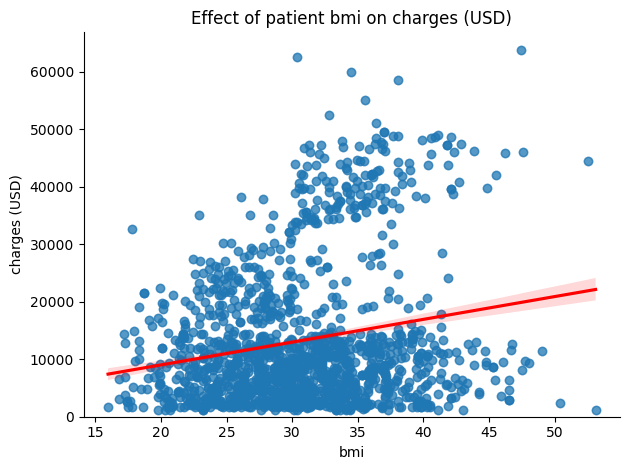

In [18]:
sns.regplot(x = "bmi" , y = "charges (USD)" , data = df_final, line_kws = {"color":"red"}, scatter_kws={"alpha": 0.5})
plt.title("Effect of patient bmi on charges (USD)")
plt.tight_layout()
plt.ylim(0,)
sns.despine()

<h2>B. Box plot</h2>
<p>Effect of smoker on charges (USD)</p>

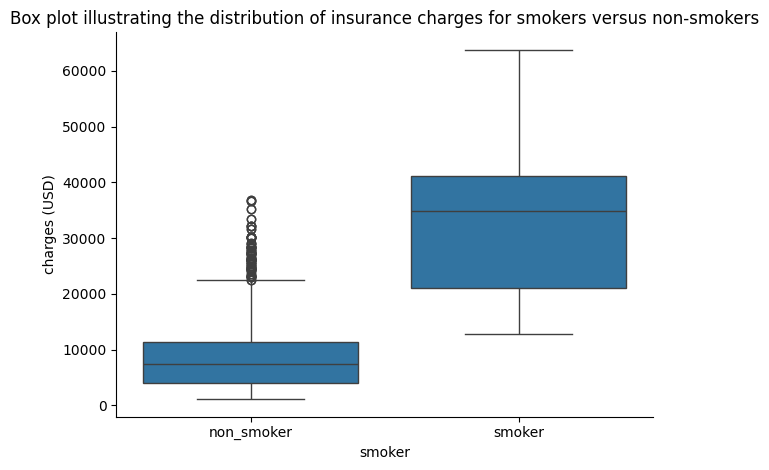

In [19]:
sns.boxplot(x = "smoker", y = "charges (USD)", data = df_final)
plt.title("Box plot illustrating the distribution of insurance charges for smokers versus non-smokers")
plt.xticks([0,1], ["non_smoker", "smoker"])
plt.tight_layout()
sns.despine()

<h2>C. Correlation Matrix and heatmap </h2>

In [20]:
corr_matrix = df_final.corr()

Text(0.5, 1.0, 'Correlation matrix of medical insurance dataset features')

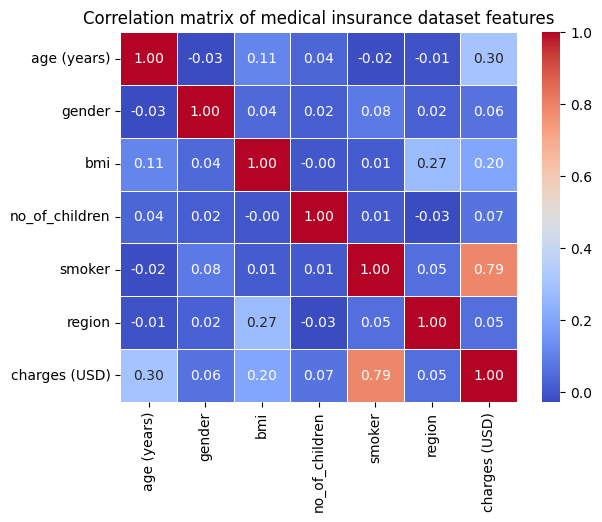

In [21]:
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", linewidth = .5)
plt.title("Correlation matrix of medical insurance dataset features")

<h2>C. Distributions </h2>

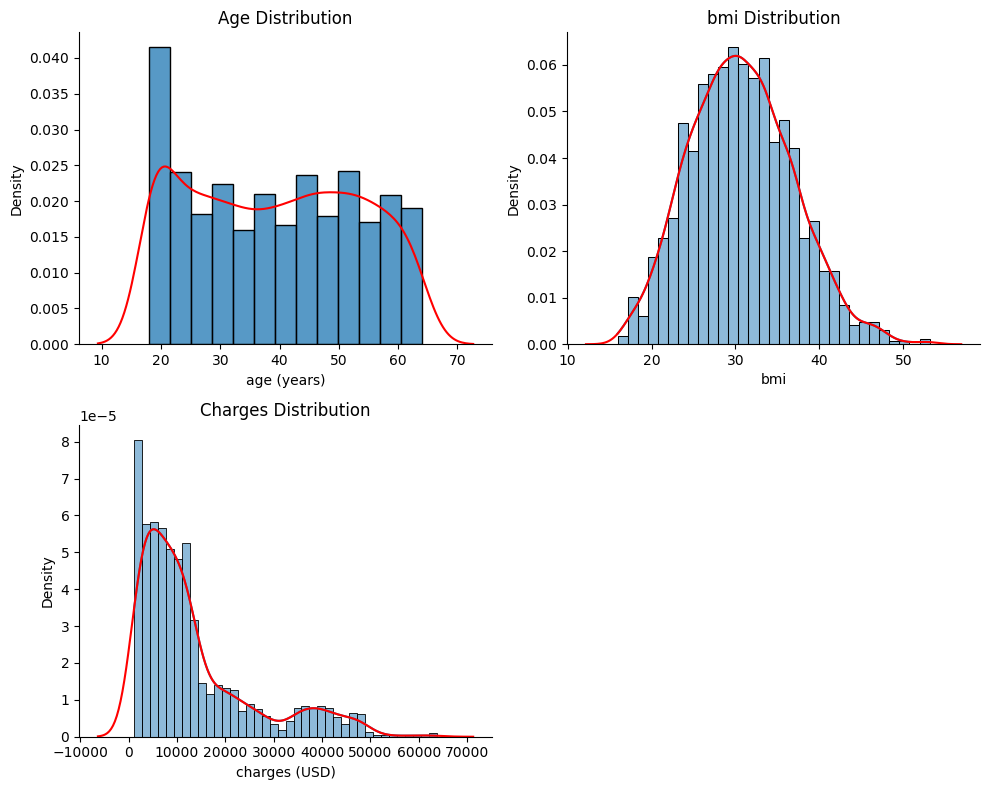

In [22]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
sns.histplot(df_final["age (years)"], bins = "auto", stat = "density", ax = axes[0,0])
sns.kdeplot(df_final["age (years)"], color="red", ax=axes[0,0])

sns.histplot(df_final["bmi"],kde = True, bins = "auto",stat = "density", ax = axes[0,1])
sns.kdeplot(df_final["bmi"], color="red", ax=axes[0,1])

sns.histplot(df_final["charges (USD)"],kde = True, bins = "auto",stat = "density", ax = axes[1,0])
sns.kdeplot(df_final["charges (USD)"], color="red", ax=axes[1,0])

fig.delaxes(axes[1][1])

axes[0,0].set_title("Age Distribution")
axes[0,1].set_title("bmi Distribution")
axes[1,0].set_title("Charges Distribution")

plt.tight_layout()
sns.despine()

<h1>III. Modele Developement and Evaluation</h1>

<h2>A. Linear Regression</h2>

<p>
A linear regression model was used to investigate the relationship between insurance charges (continuous dependent variable) and smoking status (categorical independent variable). The categorical variable was encoded as a binary indicator, where non-smokers are represented as 0 and smokers as 1. The model is defined as:
</p>

<p>
\[
\text{charges} = \beta_0 + \beta_1 \cdot \text{smoker}
\]
</p>

<p>
For non-smokers (\(\text{smoker} = 0\)), the model simplifies to:
</p>

<p>
\[
\text{charges}_{\text{non-smoker}} = \beta_0
\]
</p>

<p>
For smokers (\(\text{smoker} = 1\)), the predicted charges are:
</p>

<p>
\[
\text{charges}_{\text{smoker}} = \beta_0 + \beta_1
\]
</p>

<p>
The coefficient \(\beta_1\) represents the difference in mean insurance charges between smokers and non-smokers, expressed as:
</p>

<p>
\[
\beta_1 = \mathbb{E}(\text{charges} \mid \text{smoker}=1) - \mathbb{E}(\text{charges} \mid \text{smoker}=0)
\]
</p>

<p>
This formulation shows that the model is equivalent to comparing group means, where \(\beta_0\) represents the average charges for non-smokers and \(\beta_0 + \beta_1\) represents the average charges for smokers.
</p>

In [23]:
model_regress = LinearRegression()

model_regress.fit(df_final[["smoker"]], df_final["charges (USD)"])

R2_regress = model_regress.score(df_final[["smoker"]], df_final["charges (USD)"])

print(f"""Effect of Smoking Status on Insurance Charges Using Linear Regression: 
R² = {R2_regress:.2f}""")

Effect of Smoking Status on Insurance Charges Using Linear Regression: 
R² = 0.62


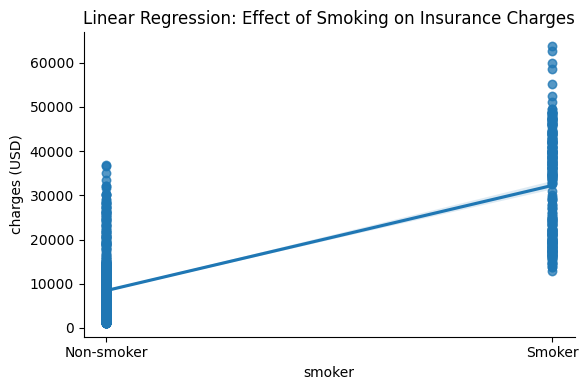

In [24]:
plt.figure(figsize=(6,4))
sns.regplot(
    x="smoker",
    y="charges (USD)",
    data=df_final,
    scatter_kws={"alpha": 0.5}
)
plt.xticks([0, 1], ["Non-smoker", "Smoker"])
plt.title("Linear Regression: Effect of Smoking on Insurance Charges")
plt.tight_layout()
sns.despine()
plt.show()

<h2>B. Multiple Regression</h2>

In [25]:
model_regress.fit(df_final[["age (years)", "gender", "bmi", "no_of_children", "smoker", "region"]], df_final["charges (USD)"])

R2_multi_regress = model_regress.score(df_final[["age (years)", "gender", "bmi", "no_of_children", "smoker", "region"]], df_final["charges (USD)"])

print(f"""Effect of age (years), gender, bmi, no_of_children, smoker, and region on Insurance Charges using multiple linear regression:
R2 = {R2_multi_regress:.2f}""")

Effect of age (years), gender, bmi, no_of_children, smoker, and region on Insurance Charges using multiple linear regression:
R2 = 0.75


<h2>C. Polynomial Regression</h2>

In [26]:
x = df_final[["age (years)", "gender", "bmi", "no_of_children", "smoker", "region"]]
y = df_final["charges (USD)"]

degrees = [2,3]
for n in degrees:
    Input = [("scale", StandardScaler()),("polynomial", PolynomialFeatures(degree = n, include_bias = False)),("model", LinearRegression())]
    pipe = Pipeline(Input)
    pipe.fit(x,y)
    y_pred = pipe.predict(x)

    R2_poly = r2_score(y, y_pred)
    
    print(f"For a {n} degree polynomial regression model, R2 = {R2_poly:.2f}")

For a 2 degree polynomial regression model, R2 = 0.85
For a 3 degree polynomial regression model, R2 = 0.85


<h2>IV. Model Refinement</h2>

<h3>A. Dataset Split</h3>

In [106]:
x = df_final[["age (years)", "gender", "bmi", "no_of_children", "smoker", "region"]]
y = df_final["charges (USD)"]

In [107]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

In [108]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(2217, 6) (555, 6)
(2217,) (555,)


<h3>B. Ridge Multiple Regression</h3>

In [109]:
model_ridge = Ridge(alpha = 0.1)
model_ridge.fit(X_train, y_train)

R2_train = model_ridge.score(X_train, y_train)
#y_pred_train = model_ridge.predict(X_train)
#R2 = r2_score(y_train, y_pred_train)
print(R2_train)
#print(R2)
y_pred_test = model_ridge.predict(X_test)
R2_test = r2_score(y_test, y_pred_test)
print(R2_test)

0.7540698492846674
0.7351910699977617


<h3>C. Ridge Multivariate 2nd Polynomial Regression</h3>

In [119]:
pr = PolynomialFeatures(degree = 2)
X_train_poly = pr.fit_transform(X_train)
X_test_poly = pr.transform(X_test)

model_ridge.fit(X_train_poly, y_train)

y_pred_train = model_ridge.predict(X_train_poly)
y_pred_test = model_ridge.predict(X_test_poly)

R2_train = r2_score(y_train, y_pred_train)
R2_test = r2_score(y_test, y_pred_test)

print(R2_train, R2_test)


0.8504790567637748 0.822307143364053
